# Sales Analytics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
orders = pd.read_csv("../data/engineered/orders_engineered.csv")
orderitems = pd.read_csv("../data/engineered/orderitems_engineered.csv")
products = pd.read_csv("../data/engineered/products_engineered.csv")
categories = pd.read_csv("../data/engineered/categories_engineered.csv")
customers = pd.read_csv("../data/engineered/customers_engineered.csv")

In [4]:
orders.shape, orderitems.shape, products.shape, categories.shape

((99441, 14), (112650, 7), (32951, 10), (71, 2))

## Revenue Overview

In [5]:
sales = orderitems.copy()

sales["revenue"] = (
    sales["price"] +
    sales["freight_value"]
)

total_revenue = sales["revenue"].sum()

print(f"Total Revenue : R$ {total_revenue:,.2f}")

Total Revenue : R$ 15,843,553.24


The total revenue represents the gross sales generated from all completed order items, including freight charges.

In [6]:
total_orders = orders["order_id"].nunique()

print(f"Total Orders : {total_orders:,}")

Total Orders : 99,441


Average Order Value measures how much revenue is generated from each order on average.

In [7]:
average_order_value = total_revenue / total_orders

print(f"Average Order Value : R$ {average_order_value:,.2f}")

Average Order Value : R$ 159.33


## Monthly Revenue Trend

In [8]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

monthly_sales = (
    orders
    .merge(
        orderitems,
        on="order_id"
    )
)

monthly_sales["revenue"] = (
    monthly_sales["price"] +
    monthly_sales["freight_value"]
)

monthly_sales["month"] = (
    monthly_sales["order_purchase_timestamp"]
    .dt
    .to_period("M")
    .astype(str)
)

monthly_revenue = (
    monthly_sales
    .groupby("month")["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,month,revenue
0,2016-09,354.75
1,2016-10,56808.84
2,2016-12,19.62
3,2017-01,137188.49
4,2017-02,286280.62


The monthly revenue trend helps identify business growth, seasonal demand, and periods of higher or lower sales activity.

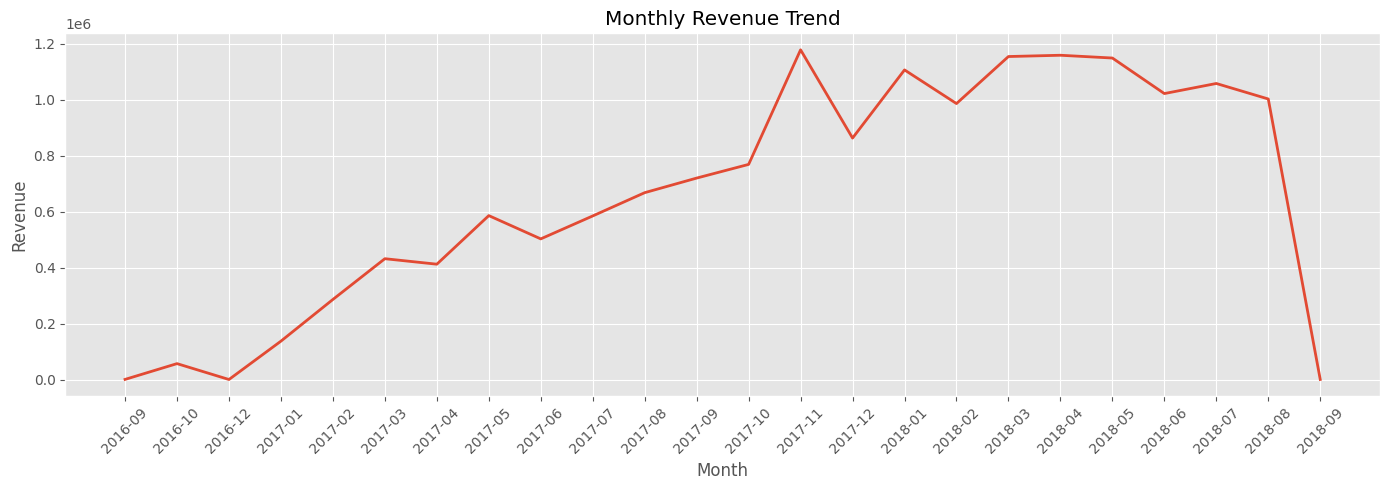

In [9]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The visualization highlights how revenue changes over time and makes it easier to identify long-term growth and seasonal fluctuations.

## Top Product Categories by Revenue

In [10]:
category_sales = (
    monthly_sales
    .merge(
        products,
        on="product_id"
    )
    .merge(
        categories,
        on="product_category_name"
    )
)

category_revenue = (
    category_sales
    .groupby("product_category_name_english")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_revenue

product_category_name_english
health_beauty            1441248.07
watches_gifts            1305541.61
bed_bath_table           1241681.72
sports_leisure           1156656.48
computers_accessories    1059272.40
furniture_decor           902511.79
housewares                778397.77
cool_stuff                719329.95
auto                      685384.32
garden_tools              584219.21
Name: revenue, dtype: float64

The highest revenue generating categories indicate which product segments contribute the most to the business and where future investments can be prioritized.

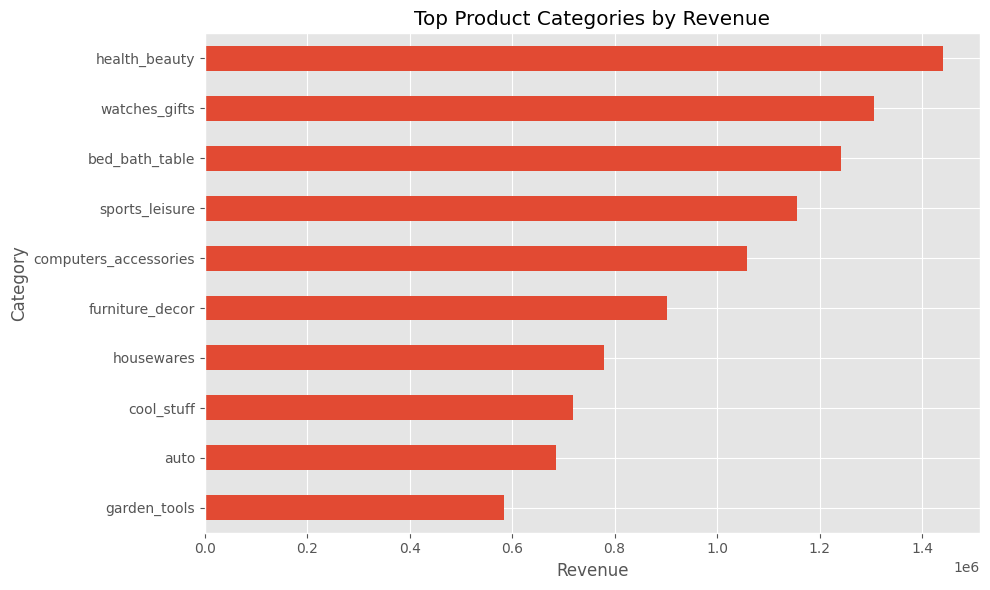

In [11]:
plt.figure(figsize=(10,6))

category_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Top Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

The chart highlights the top revenue generating product categories. Understanding category performance helps improve inventory planning, promotional strategies, and product portfolio decisions.

## Best Selling Products

In [12]:
product_revenue = (
    category_sales
    .groupby("product_id")
    .agg(
        revenue=("revenue", "sum"),
        category=("product_category_name_english", "first")
    )
    .sort_values(
        by="revenue",
        ascending=False
    )
    .head(10)
)

product_revenue

,revenue,category
product_id,,
bb50f2e236e5eea0100680137654686c,67606.10,health_beauty
d1c427060a0f73f6b889a5c7c61f2ac4,60976.03,computers_accessories
6cdd53843498f92890544667809f1595,59093.99,health_beauty
99a4788cb24856965c36a24e339b6058,51071.60,bed_bath_table
d6160fb7873f184099d9bc95e30376af,50326.18,computers
3dd2a17168ec895c781a9191c1e95ad7,48212.22,computers_accessories
aca2eb7d00ea1a7b8ebd4e68314663af,44820.76,furniture_decor
5f504b3a1c75b73d6151be81eb05bdc9,41725.81,cool_stuff
25c38557cf793876c5abdd5931f922db,40311.95,baby


The highest revenue generating products represent the company's strongest performing items and reveal where customer demand is concentrated.

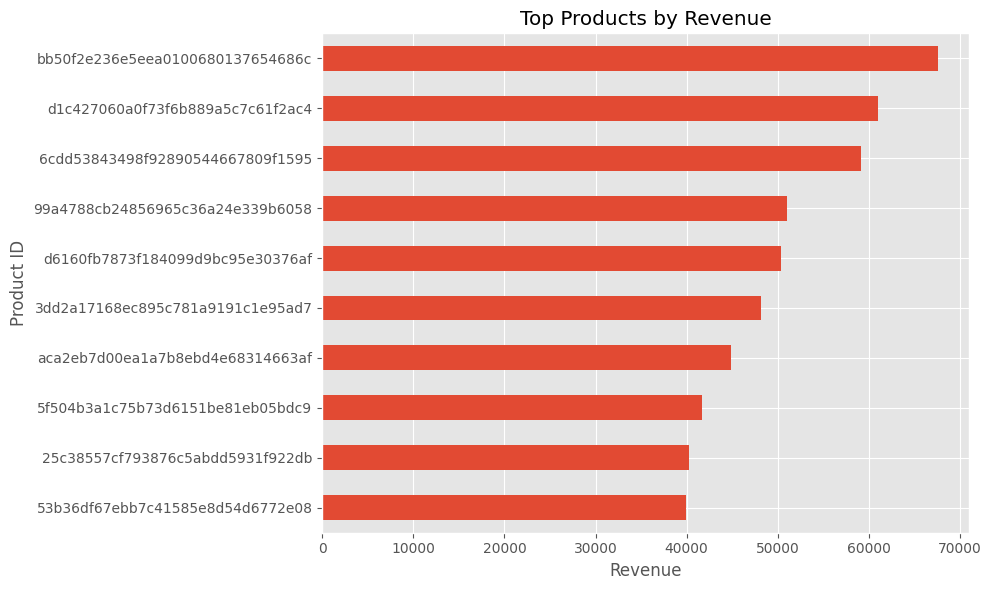

In [13]:
plt.figure(figsize=(10,6))

product_revenue["revenue"].sort_values().plot(
    kind="barh"
)

plt.title("Top Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product ID")

plt.tight_layout()

plt.show()

The visualization identifies the products responsible for the highest revenue contribution. These products can be prioritized for inventory planning, marketing campaigns, and pricing strategies.

## Top States by Revenue

In [14]:
state_sales = (
    monthly_sales
    .merge(
        customers,
        on="customer_id"
    )
)

state_revenue = (
    state_sales
    .groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_revenue

customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
Name: revenue, dtype: float64

Revenue distribution across states helps identify the strongest markets and regions with the highest customer spending.

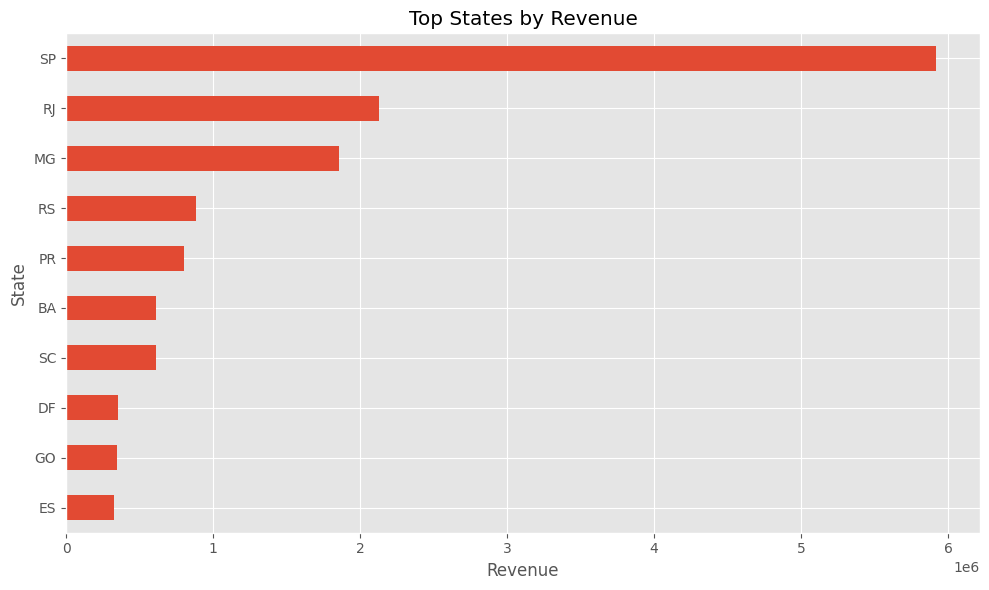

In [15]:
plt.figure(figsize=(10,6))

state_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Top States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")

plt.tight_layout()

plt.show()

The chart shows the states generating the highest revenue. These regions can be prioritized for customer retention, targeted marketing campaigns, and future business expansion.

## Monthly Orders Trend

In [16]:
monthly_orders = (
    orders
    .groupby(
        orders["order_purchase_timestamp"]
        .dt
        .to_period("M")
        .astype(str)
    )["order_id"]
    .nunique()
    .reset_index()
)

monthly_orders.columns = [
    "month",
    "orders"
]

monthly_orders.head()

,month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


Tracking monthly order volume helps evaluate customer demand, business growth, and seasonal purchasing behavior.

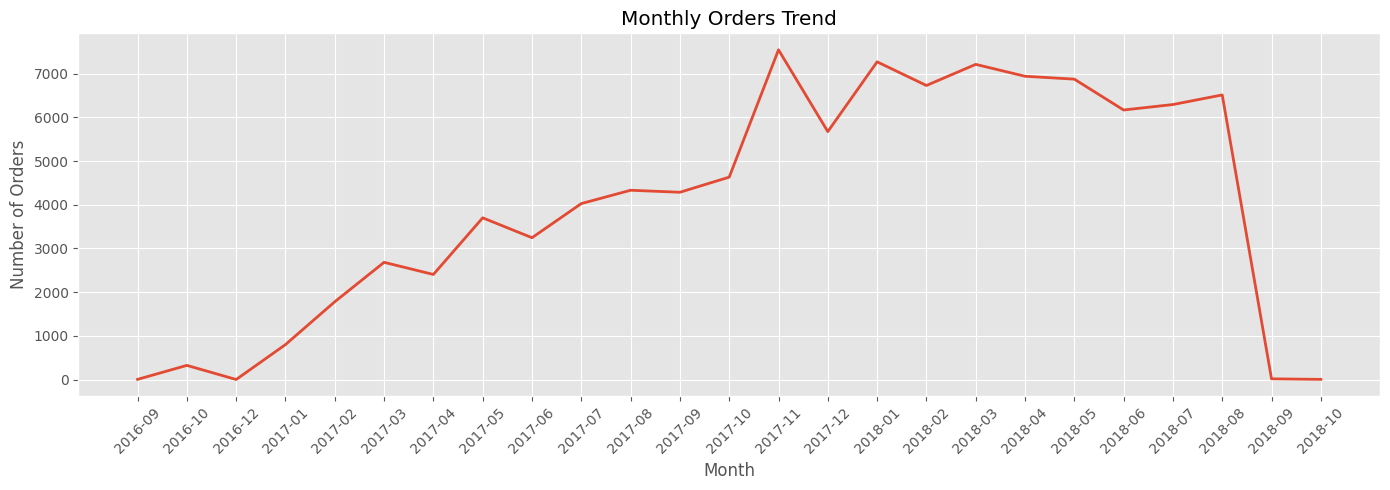

In [17]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_orders["month"],
    monthly_orders["orders"],
    linewidth=2
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The trend illustrates how customer purchasing activity changes over time and highlights periods of increased or decreased demand.

# Key Insights

- Revenue is distributed unevenly across product categories.
- A small number of products contribute a significant share of total sales.
- Customer demand varies across different states.
- Monthly revenue and order volume reveal seasonal fluctuations and long-term business growth.

# Business Recommendations

- Focus marketing investments on the highest revenue generating categories.
- Improve inventory planning for top selling products.
- Expand customer acquisition in states with strong purchasing activity.
- Prepare promotional campaigns around seasonal demand patterns.